# Retinal Disease Classification Demo

This notebook demonstrates a retinal disease classification pipeline:

1. **Dataset exploration**: Load the sampled dataset and visualize sample images from different classes.
2. **Model loading**: Automatically load the latest trained SqueezeNet classification model.
3. **Single-image prediction and visualization**: Run prediction on one random image and show confidence scores with a bar chart.

### Preparation: Import Required Libraries and Project Modules
Import all required libraries for the classification task.

In [13]:
import os
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, models
from PIL import Image
import numpy as np
import json
import random
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
try:
    # Assume the notebook is inside the classification folder
    from utils import get_data_transforms, get_class_names
except ImportError:
    print("Module import failed. Confirm that the notebook working directory is correct.")

import warnings
warnings.filterwarnings('ignore')

print("All libraries and modules were imported successfully.")


All libraries and modules were imported successfully.


### Step 1: configure, load, and explore the dataset

Load the sampled dataset and display random images from several classes to get a quick overview.


Dataset loaded successfully. Found 39 classes.
Class list: ['0.0.Normal', '0.1.Tessellated fundus', '0.2.Large optic cup', '0.3.DR1', '1.0.DR2', '1.1.DR3', '10.0.Possible glaucoma', '10.1.Optic atrophy', '11.Severe hypertensive retinopathy', '12.Disc swelling and elevation', '13.Dragged Disc', '14.Congenital disc abnormality', '15.0.Retinitis pigmentosa', '15.1.Bietti crystalline dystrophy', '16.Peripheral retinal degeneration and break', '17.Myelinated nerve fiber', '18.Vitreous particles', '19.Fundus neoplasm', '2.0.BRVO', '2.1.CRVO', '20.Massive hard exudates', '21.Yellow-white spots-flecks', '22.Cotton-wool spots', '23.Vessel tortuosity', '24.Chorioretinal atrophy-coloboma', '25.Preretinal hemorrhage', '26.Fibrosis', '27.Laser Spots', '28.Silicon oil in eye', '29.0.Blur fundus without PDR', '29.1.Blur fundus with suspected PDR', '3.RAO', '4.Rhegmatogenous RD', '5.0.CSCR', '5.1.VKH disease', '6.Maculopathy', '7.ERM', '8.MH', '9.Pathological myopia']


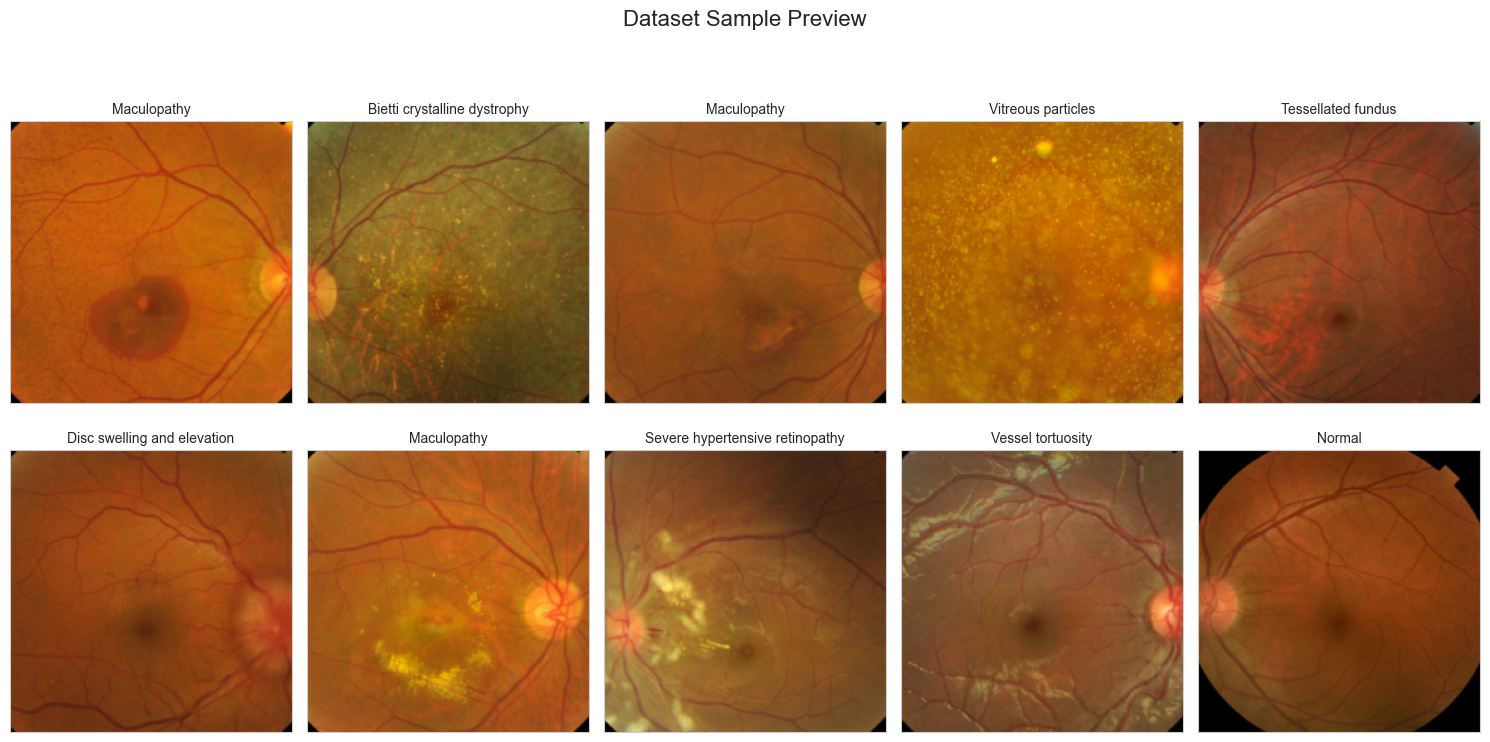

In [14]:
# --- Configuration ---
DATASET_DIR = r'.\datasets\sampled_images'
OUTPUTS_DIR = r'.\outputs'

# --- Load dataset ---
# Use ImageFolder to load data
data_transforms = get_data_transforms()
full_dataset = datasets.ImageFolder(DATASET_DIR, transform=data_transforms['val']) # Use validation transforms for visualization
class_names = full_dataset.classes
print(f"Dataset loaded successfully. Found {len(class_names)} classes.")
print("Class list:", class_names)

# --- Visualize dataset samples ---
def show_dataset_samples(dataset, num_samples=10):
    fig = plt.figure(figsize=(15, 8))
    plt.suptitle("Dataset Sample Preview", fontsize=16)
    
    indices = random.sample(range(len(dataset)), num_samples)
    
    for i, idx in enumerate(indices):
        image, label_idx = dataset[idx]
        ax = fig.add_subplot(2, 5, i + 1, xticks=[], yticks=[])
        
        # De-normalize image for display
        image = image.numpy().transpose((1, 2, 0))
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        image = std * image + mean
        image = np.clip(image, 0, 1)
        
        ax.imshow(image)
        ax.set_title(class_names[label_idx].split('.')[-1], fontsize=10) # Show shorter class names
        
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

show_dataset_samples(full_dataset)


### Step 2: load the trained model

Automatically find and load the latest classification model.

In [15]:
# --- Automatically find latest model ---
def get_latest_model_path(output_dir):
    try:
        subdirs = [d for d in os.listdir(output_dir) if os.path.isdir(os.path.join(output_dir, d))]
        if not subdirs: return None, None
        latest_dir = sorted(subdirs)[-1]
        model_path = os.path.join(output_dir, latest_dir, 'best_model.pth')
        class_names_path = os.path.join(output_dir, latest_dir, 'class_names.json')
        return model_path if os.path.exists(model_path) else None, class_names_path
    except FileNotFoundError:
        return None, None

MODEL_PATH, CLASS_NAMES_PATH = get_latest_model_path(OUTPUTS_DIR)
if not MODEL_PATH:
    raise FileNotFoundError(f"No model found in '{OUTPUTS_DIR}'. Run train_model.py first.")

print(f"Model selected: {MODEL_PATH}")

# --- Load class names ---
with open(CLASS_NAMES_PATH, 'r') as f:
    loaded_class_names = json.load(f)
num_classes = len(loaded_class_names)

# --- Load model ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = models.squeezenet1_1(pretrained=False)
model.classifier[1] = nn.Conv2d(512, num_classes, kernel_size=(1,1), stride=(1,1))
model.num_classes = num_classes
model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
model.to(device)
model.eval()

print(f"Model loaded successfully on device: {device}")


Model selected: .\outputs\20260307-215950\best_model.pth
Model loaded successfully on device: cpu


### Step 3: single-image prediction and confidence visualization

This section runs prediction on one random image and shows confidence scores for the most likely classes.

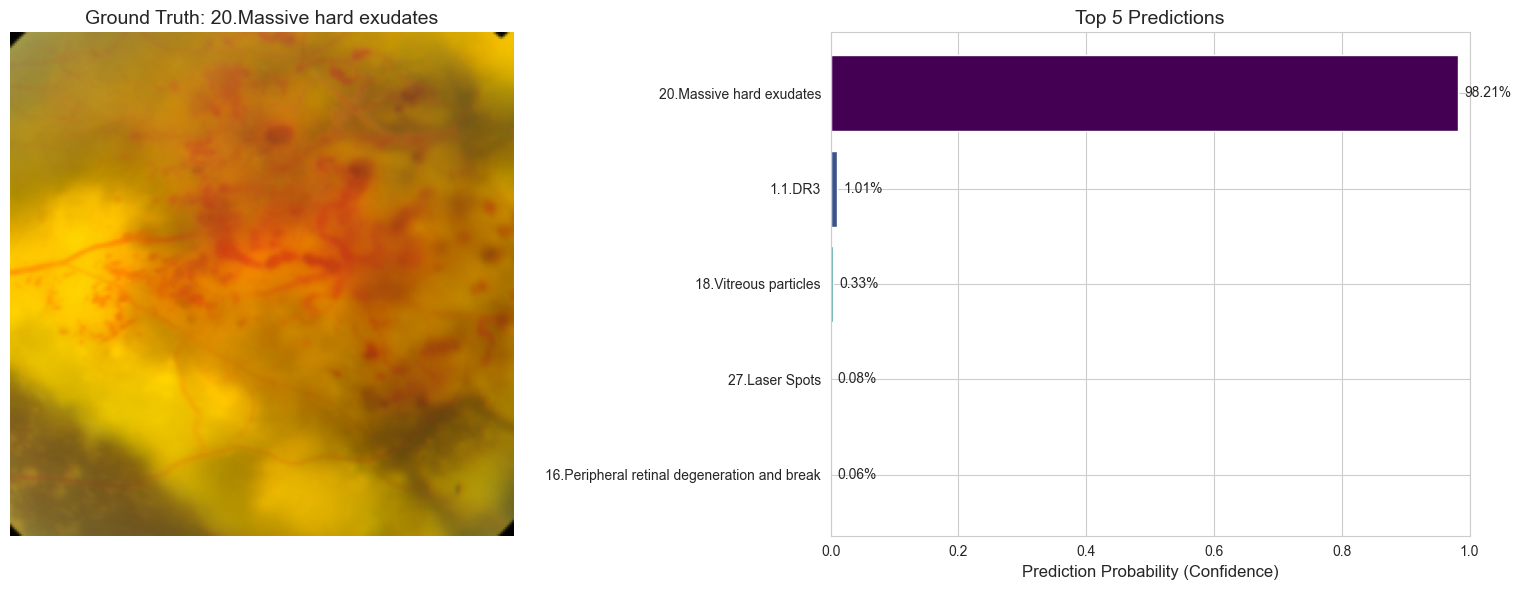

In [16]:

sample_idx = random.randint(0, len(full_dataset) - 1)
image, true_label_idx = full_dataset[sample_idx]
true_label_name = loaded_class_names[true_label_idx]

# --- Model prediction ---
input_tensor = image.unsqueeze(0).to(device)
with torch.no_grad():
    output = model(input_tensor)
    probabilities = torch.nn.functional.softmax(output[0], dim=0)
    top5_prob, top5_indices = torch.topk(probabilities, 5)

# --- Visualize prediction ---
# De-normalize image
image_to_show = image.numpy().transpose((1, 2, 0))
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])
image_to_show = std * image_to_show + mean
image_to_show = np.clip(image_to_show, 0, 1)

# Prepare bar chart data
top5_labels = [loaded_class_names[i] for i in top5_indices.cpu().numpy()]
top5_probs_values = top5_prob.cpu().numpy()

# Create side-by-side plots
fig, (ax1, ax2) = plt.subplots(figsize=(16, 6), ncols=2)

# Show image
ax1.imshow(image_to_show)
ax1.set_title(f"Ground Truth: {true_label_name}", fontsize=14)
ax1.axis('off')

# Show bar chart
bars = ax2.barh(top5_labels, top5_probs_values, color=plt.cm.viridis(np.linspace(0, 1, 5)))
ax2.set_xlabel('Prediction Probability (Confidence)', fontsize=12)
ax2.set_title('Top 5 Predictions', fontsize=14)
ax2.invert_yaxis() # Highest probability at the top
ax2.set_xlim(0, 1.0)
# Add values on bars
for bar in bars:
    ax2.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2, f'{bar.get_width():.2%}', va='center')

plt.tight_layout()
plt.show()
